<a href="https://colab.research.google.com/github/vaghelazeel/RIDDOR-Workplace-Injury-Analysis/blob/main/RIDDOR_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found: ridhist.xlsx
Found: ridagegen.xlsx
Libraries loaded successfully
Fatal data loaded: (39, 4)
                           Year  Fatal
34  2020/21 [Note 19] [Note 20]     89
35  2021/22 [Note 19] [Note 20]     83
36                      2022/23     92
37                     2023/24r     88
38                     2024/25p     75
Non-fatal data loaded: (26, 5)
       Year  Nonfatal
21  2007/08    138253
22  2008/09    133155
23  2009/10    122695
24  2010/11    116686
25  2011/12    111299
Age/gender data loaded: (5625, 5)
Latest reporting year: 2024/25p


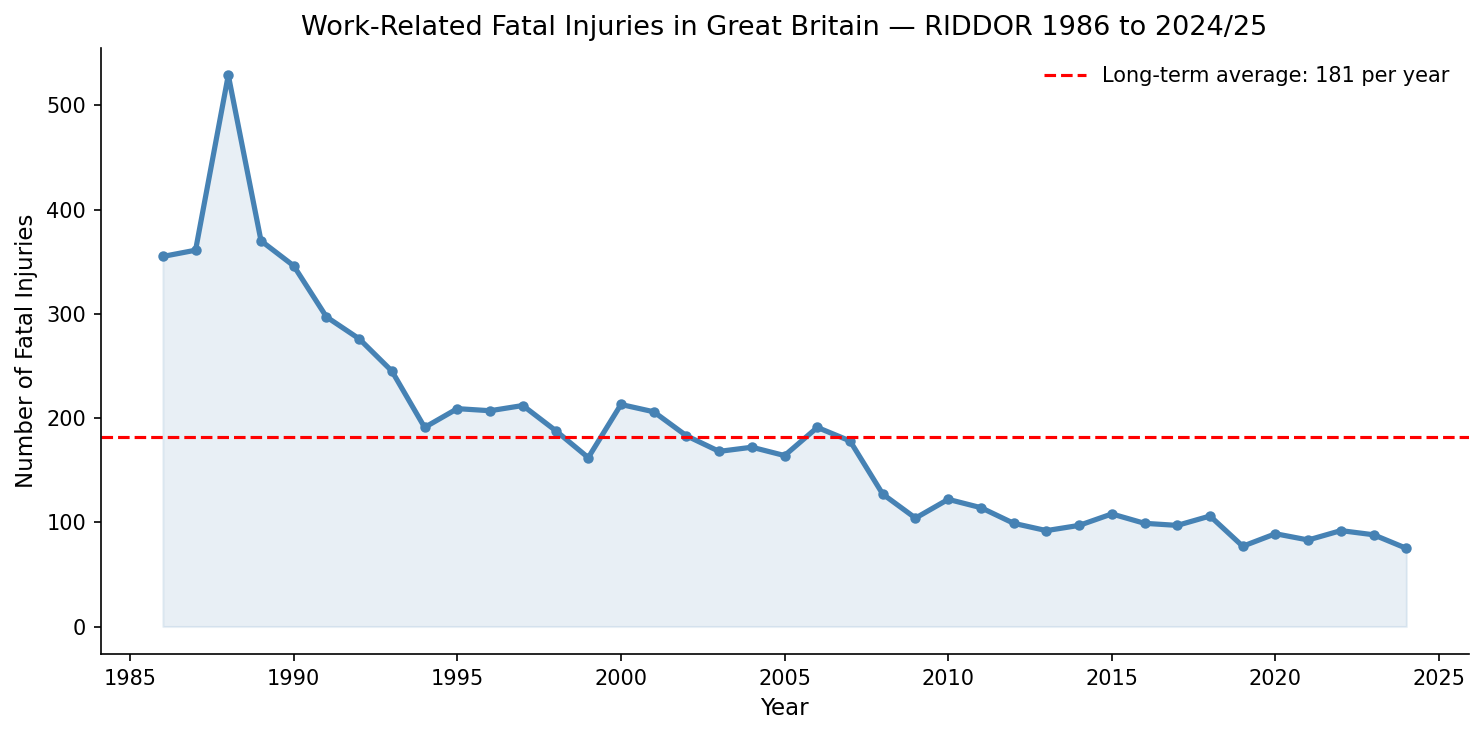

Fatal 1986: 355
Fatal latest: 75
Reduction: 78.9%
Saved fig1_fatal_trend.png


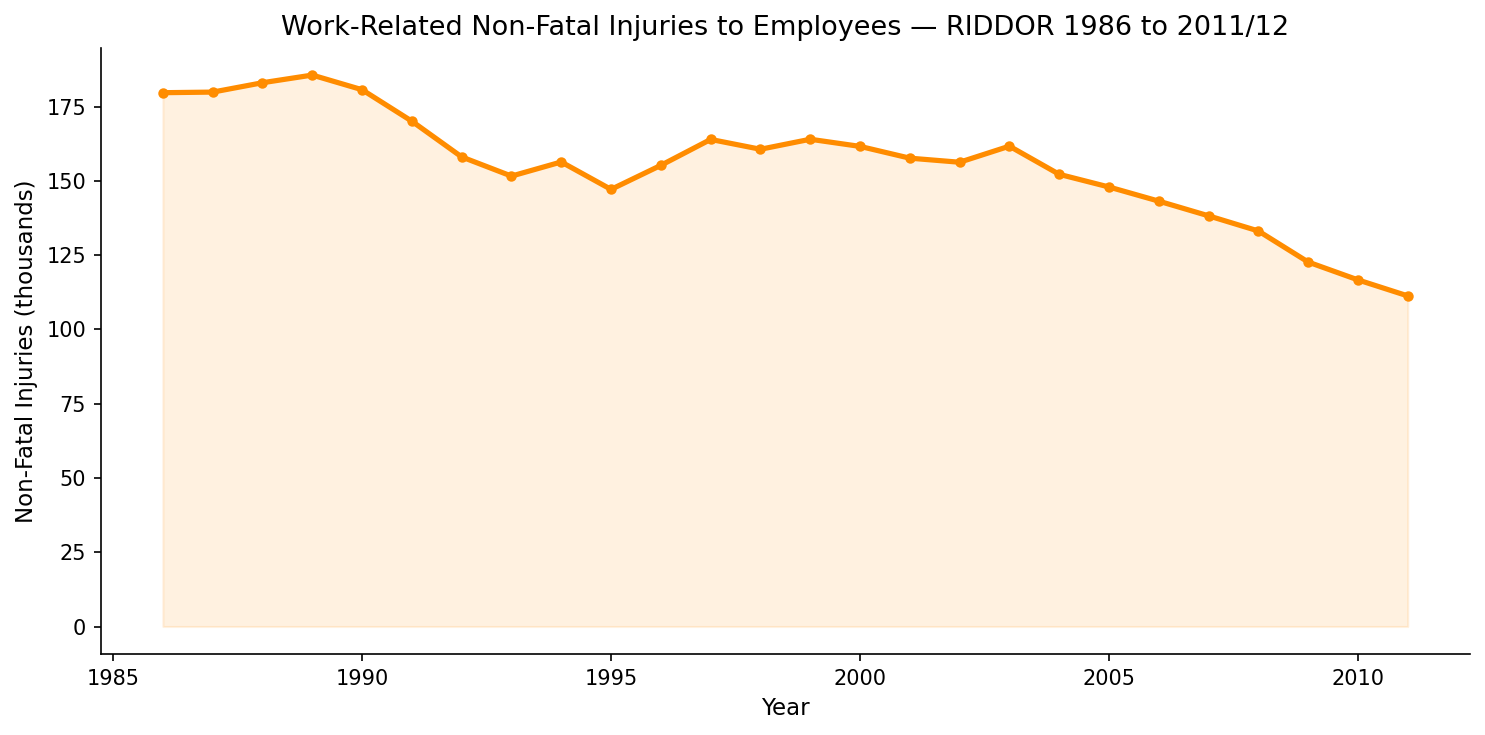

Saved fig2_nonfatal_trend.png


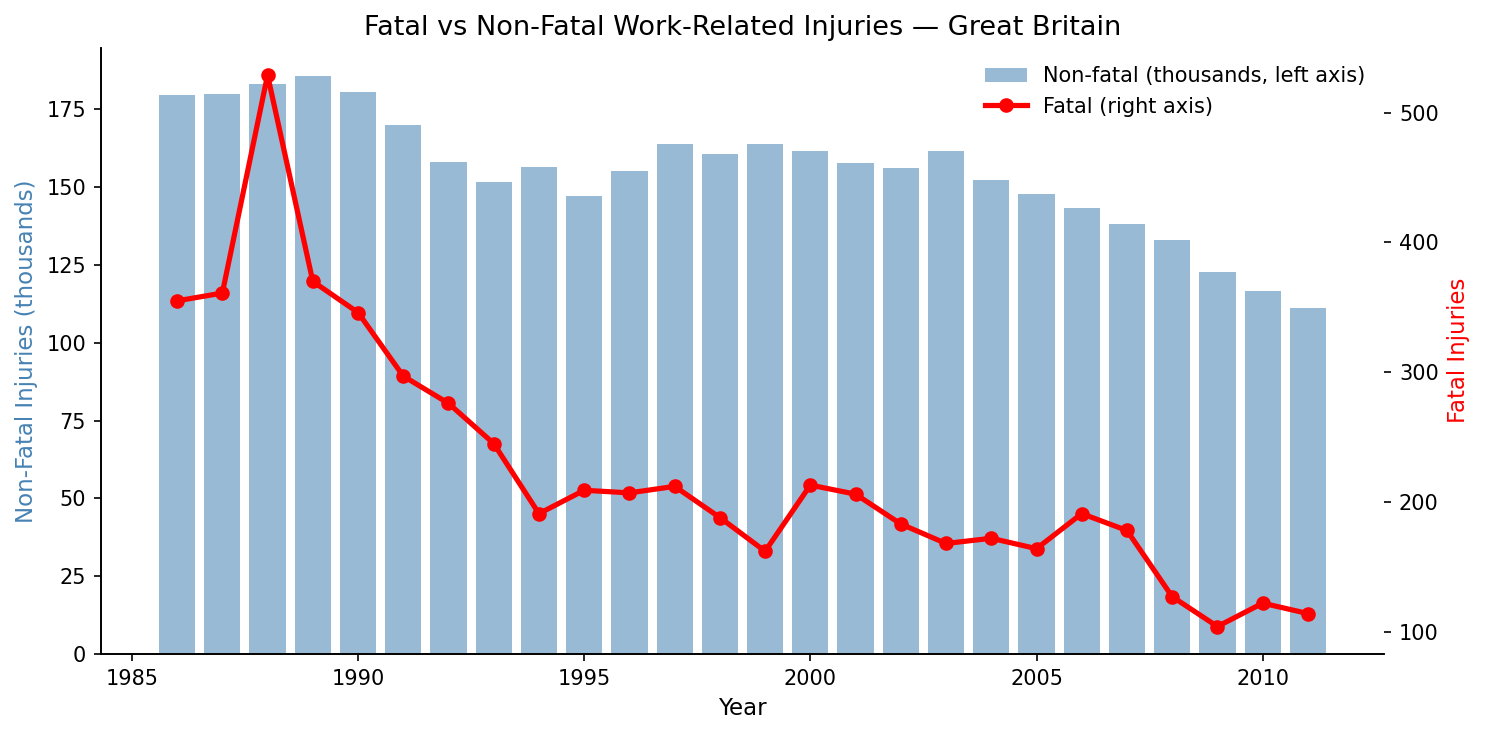

Saved fig3_fatal_vs_nonfatal.png


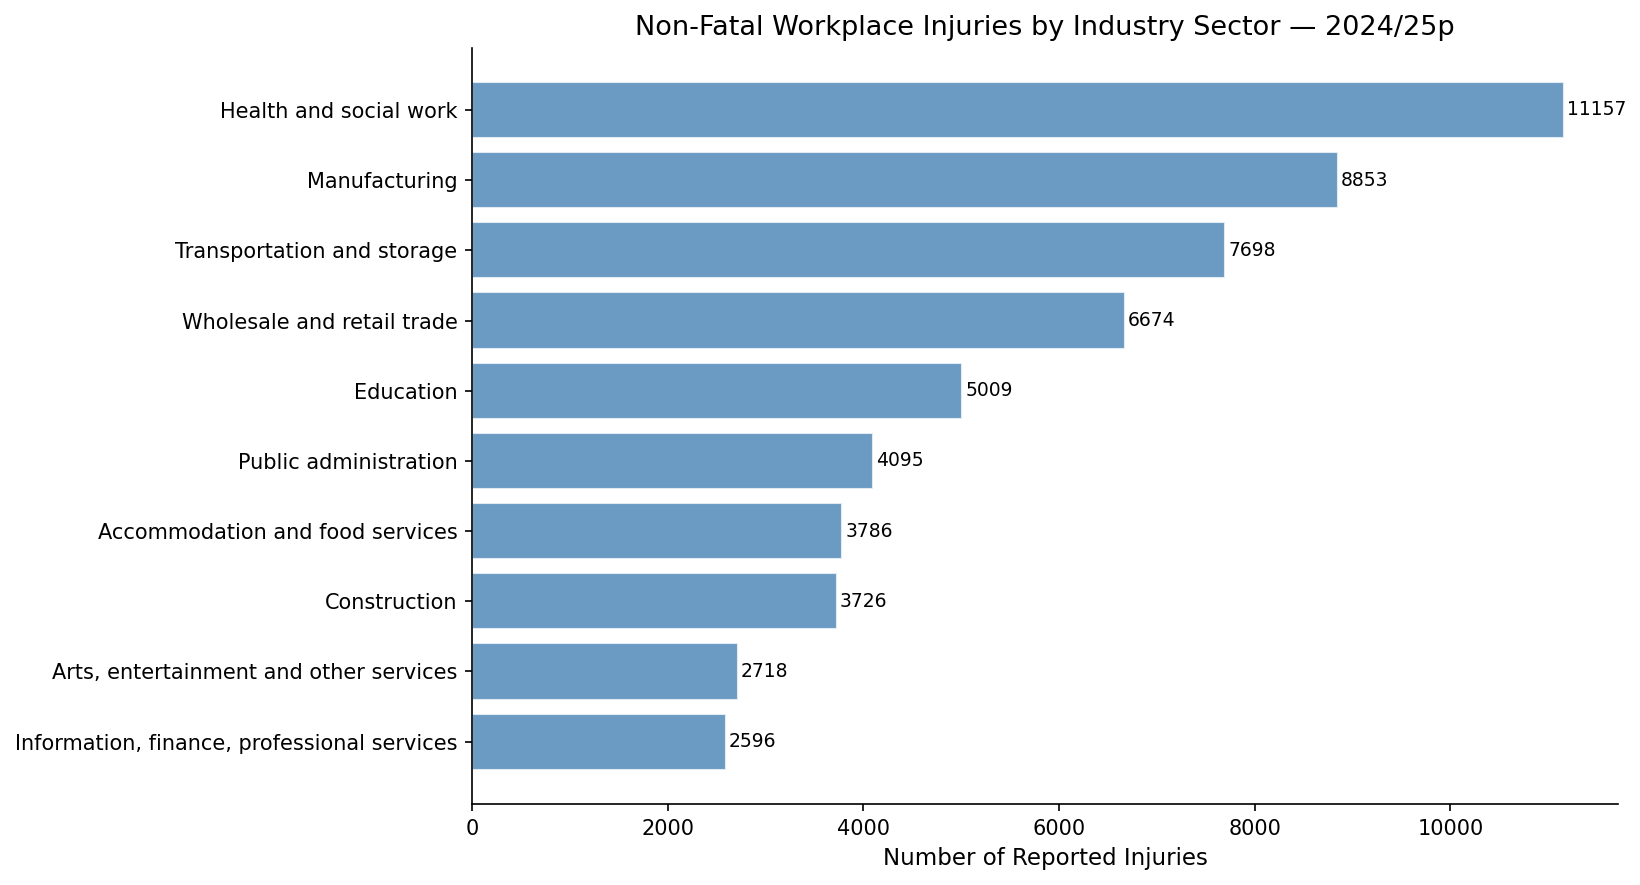

Saved fig4_injuries_by_industry.png


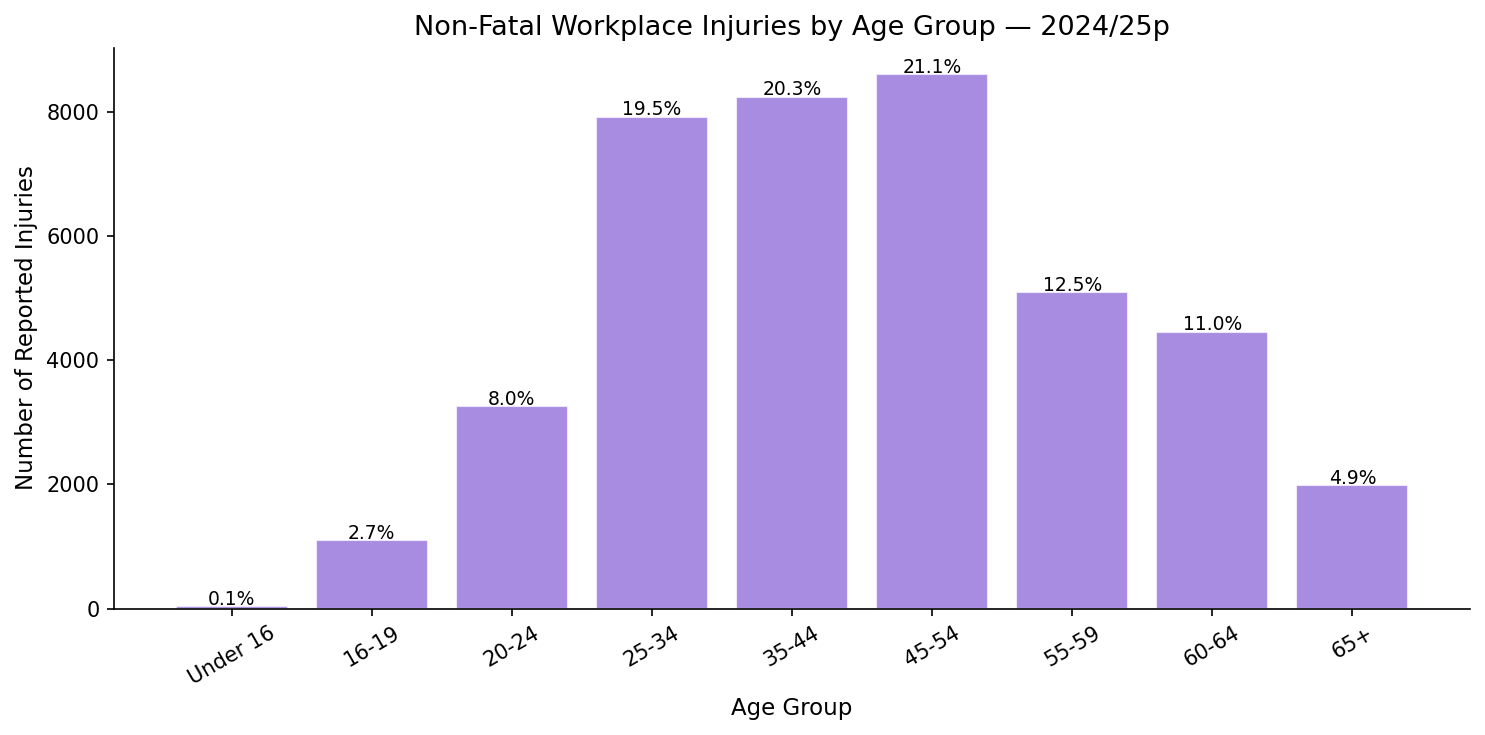

Saved fig5_injuries_by_age.png


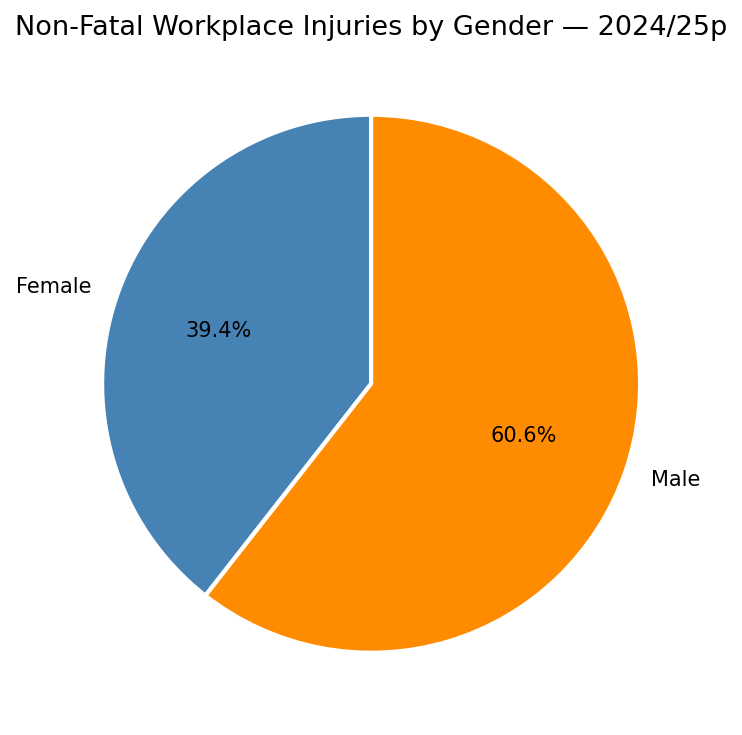

Saved fig6_injuries_by_gender.png
Analysis Complete
----------------------------------------
Fatal injuries 1986: 355
Fatal injuries latest year: 75
Total reduction: 78.9%
Highest injury burden sector: Health and social work
Highest injury age group: 45-54

Saved: fig1_fatal_trend.png
Saved: fig2_nonfatal_trend.png
Saved: fig3_fatal_vs_nonfatal.png
Saved: fig4_injuries_by_industry.png
Saved: fig5_injuries_by_age.png
Saved: fig6_injuries_by_gender.png

Download all 6 figures from the Files panel on the left side of Colab.


In [1]:
# RIDDOR Workplace Injury Analysis — HSE Great Britain Data
# Author: Zeel Vaghela, MSc Bioinformatics | NEBOSH NGC (in progress)
# Data source: Health and Safety Executive (HSE), UK Government
# Run each cell one at a time in Google Colab


# CELL 1 - Install libraries
!pip install -q pandas numpy matplotlib seaborn openpyxl


# CELL 2 - Import libraries and verify files
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

FP_RIDHIST   = "/content/ridhist.xlsx"
FP_RIDAGEGEN = "/content/ridagegen.xlsx"
SAVE_DIR     = "/content"

for f in [FP_RIDHIST, FP_RIDAGEGEN]:
    print("Found:" if os.path.exists(f) else "MISSING:", os.path.basename(f))

print("Libraries loaded successfully")


# CELL 3 - Load fatal injury data 1986 to present
raw = pd.read_excel(FP_RIDHIST, sheet_name="Table 1", header=None)
df_fatal = raw.iloc[8:, [0, 1, 6]].copy()
df_fatal.columns = ["Year", "Industry", "Fatal"]
df_fatal = df_fatal[df_fatal["Industry"] == "All industries"].copy()
df_fatal["Fatal"] = pd.to_numeric(df_fatal["Fatal"], errors="coerce")
df_fatal = df_fatal.dropna(subset=["Fatal"])

def parse_year(y):
    y = str(y).strip()
    try:
        return int(y.split("/")[0])
    except:
        return None

df_fatal["Yr"] = df_fatal["Year"].apply(parse_year)
df_fatal = df_fatal.dropna(subset=["Yr"])
df_fatal["Yr"] = df_fatal["Yr"].astype(int)
df_fatal = df_fatal[df_fatal["Yr"] >= 1986].reset_index(drop=True)

print("Fatal data loaded:", df_fatal.shape)
print(df_fatal[["Year", "Fatal"]].tail(5).to_string())


# CELL 4 - Load non-fatal injury data 1986 to 2011/12
raw3 = pd.read_excel(FP_RIDHIST, sheet_name="Table 3", header=None)
df_nf = raw3.iloc[8:, [0, 1, 2, 6]].copy()
df_nf.columns = ["Status", "Year", "Industry", "Nonfatal"]
df_nf = df_nf[
    (df_nf["Status"] == "Employee") &
    (df_nf["Industry"] == "All industries")
].copy()
df_nf["Nonfatal"] = pd.to_numeric(df_nf["Nonfatal"], errors="coerce")
df_nf = df_nf.dropna(subset=["Nonfatal"])
df_nf["Yr"] = df_nf["Year"].apply(parse_year)
df_nf = df_nf.dropna(subset=["Yr"])
df_nf["Yr"] = df_nf["Yr"].astype(int)
df_nf = df_nf[df_nf["Yr"] >= 1986].reset_index(drop=True)

print("Non-fatal data loaded:", df_nf.shape)
print(df_nf[["Year", "Nonfatal"]].tail(5).to_string())


# CELL 5 - Load age gender breakdown data
raw_age = pd.read_excel(FP_RIDAGEGEN, sheet_name="Table 2", header=None)
df_age = raw_age.iloc[8:, [0, 2, 3, 4, 5]].copy()
df_age.columns = ["Year", "Industry", "Gender", "Age_group", "Total"]
df_age["Total"] = pd.to_numeric(df_age["Total"], errors="coerce")
df_age = df_age.dropna(subset=["Total"])

latest_year = df_age["Year"].iloc[-1]
print("Age/gender data loaded:", df_age.shape)
print("Latest reporting year:", latest_year)


# CELL 6 - Figure 1: Fatal injury trend 1986 to 2024/25
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_fatal["Yr"], df_fatal["Fatal"],
        color="steelblue", linewidth=2.5, marker="o", markersize=4)
ax.fill_between(df_fatal["Yr"], df_fatal["Fatal"], alpha=0.12, color="steelblue")
ax.axhline(df_fatal["Fatal"].mean(), color="red", linestyle="--", linewidth=1.5,
           label="Long-term average: " + str(int(df_fatal["Fatal"].mean())) + " per year")

ax.set_title("Work-Related Fatal Injuries in Great Britain — RIDDOR 1986 to 2024/25")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Fatal Injuries")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(SAVE_DIR + "/fig1_fatal_trend.png", dpi=200, bbox_inches="tight")
plt.show()

print("Fatal 1986:", int(df_fatal["Fatal"].iloc[0]))
print("Fatal latest:", int(df_fatal["Fatal"].iloc[-1]))
print("Reduction:", str(round((1 - df_fatal["Fatal"].iloc[-1] / df_fatal["Fatal"].iloc[0]) * 100, 1)) + "%")
print("Saved fig1_fatal_trend.png")


# CELL 7 - Figure 2: Non-fatal injury trend 1986 to 2011/12
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_nf["Yr"], df_nf["Nonfatal"] / 1000,
        color="darkorange", linewidth=2.5, marker="o", markersize=4)
ax.fill_between(df_nf["Yr"], df_nf["Nonfatal"] / 1000, alpha=0.12, color="darkorange")

ax.set_title("Work-Related Non-Fatal Injuries to Employees — RIDDOR 1986 to 2011/12")
ax.set_xlabel("Year")
ax.set_ylabel("Non-Fatal Injuries (thousands)")
plt.tight_layout()
plt.savefig(SAVE_DIR + "/fig2_nonfatal_trend.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig2_nonfatal_trend.png")


# CELL 8 - Figure 3: Fatal vs non-fatal overlapping years
df_both = pd.merge(df_fatal[["Yr", "Fatal"]], df_nf[["Yr", "Nonfatal"]], on="Yr", how="inner")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(df_both["Yr"], df_both["Nonfatal"] / 1000,
        color="steelblue", alpha=0.55, label="Non-fatal (thousands, left axis)")
ax2.plot(df_both["Yr"], df_both["Fatal"],
         color="red", linewidth=2.5, marker="o", markersize=6,
         label="Fatal (right axis)")

ax1.set_xlabel("Year")
ax1.set_ylabel("Non-Fatal Injuries (thousands)", color="steelblue")
ax2.set_ylabel("Fatal Injuries", color="red")
ax1.set_title("Fatal vs Non-Fatal Work-Related Injuries — Great Britain")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig(SAVE_DIR + "/fig3_fatal_vs_nonfatal.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig3_fatal_vs_nonfatal.png")


# CELL 9 - Figure 4: Non-fatal injuries by industry sector
df_ind = df_age[
    (df_age["Year"] == latest_year) &
    (df_age["Gender"] == "All") &
    (df_age["Age_group"] == "All") &
    (df_age["Industry"] != "All industries")
].copy()

df_ind = df_ind.groupby("Industry")["Total"].sum().reset_index()
df_ind = df_ind.sort_values("Total", ascending=True).tail(10)

def shorten(name):
    lookup = {
        "Agriculture, forestry and fishing [Note 9]": "Agriculture",
        "Mining and quarrying [Note 3]": "Mining and quarrying",
        "Wholesale and retail trade; repair of motor vehicles and motorcycles": "Wholesale and retail trade",
        "Transportation and storage [Note 2]": "Transportation and storage",
        "Information and communication; financial and insurance activities; real estate activities; professional, scientific and technical activities; administrative and support service activities": "Information, finance, professional services",
        "Public administration and defence; compulsory social security": "Public administration",
        "Human health and social work activities": "Health and social work",
        "Arts, entertainment and recreation; other service activities; activities of households as employers; undifferentiated goods-and services-producing activities of households for own use; activities of extraterritorial organisations and bodies": "Arts, entertainment and other services",
        "Water supply; sewerage, waste management and remediation activities": "Water supply and waste management",
        "Electricity, gas, steam and air conditioning supply": "Electricity and gas supply",
        "Accommodation and food service activities": "Accommodation and food services",
    }
    return lookup.get(name, name)

df_ind["Industry_short"] = df_ind["Industry"].apply(shorten)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(df_ind["Industry_short"], df_ind["Total"],
               color="steelblue", alpha=0.8, edgecolor="white")

for bar, val in zip(bars, df_ind["Total"]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va="center", fontsize=9)

ax.set_title("Non-Fatal Workplace Injuries by Industry Sector — " + str(latest_year))
ax.set_xlabel("Number of Reported Injuries")
plt.tight_layout()
plt.savefig(SAVE_DIR + "/fig4_injuries_by_industry.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig4_injuries_by_industry.png")


# CELL 10 - Figure 5: Non-fatal injuries by age group
df_ag = df_age[
    (df_age["Year"] == latest_year) &
    (df_age["Gender"] == "All") &
    (df_age["Industry"] == "All industries") &
    (~df_age["Age_group"].isin(["All", "Unknown [Note 13]"]))
].copy()

df_ag = df_ag.groupby("Age_group")["Total"].sum().reset_index()

age_order = ["Under 16", "16-19", "20-24", "25-34", "35-44", "45-54", "55-59", "60-64", "65+"]
df_ag["Age_group"] = pd.Categorical(df_ag["Age_group"], categories=age_order, ordered=True)
df_ag = df_ag.sort_values("Age_group").dropna(subset=["Age_group"])

total_age = df_ag["Total"].sum()
df_ag["Pct"] = (df_ag["Total"] / total_age * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df_ag["Age_group"].astype(str), df_ag["Total"],
              color="mediumpurple", alpha=0.8, edgecolor="white")

for bar, pct in zip(bars, df_ag["Pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(pct) + "%", ha="center", fontsize=9)

ax.set_title("Non-Fatal Workplace Injuries by Age Group — " + str(latest_year))
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Reported Injuries")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(SAVE_DIR + "/fig5_injuries_by_age.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig5_injuries_by_age.png")


# CELL 11 - Figure 6: Injuries by gender
df_gen = df_age[
    (df_age["Year"] == latest_year) &
    (df_age["Industry"] == "All industries") &
    (df_age["Age_group"] == "All") &
    (df_age["Gender"].isin(["Male", "Female"]))
].copy()

df_gen = df_gen.groupby("Gender")["Total"].sum().reset_index()

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(
    df_gen["Total"],
    labels=df_gen["Gender"],
    autopct="%1.1f%%",
    colors=["steelblue", "darkorange"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
ax.set_title("Non-Fatal Workplace Injuries by Gender — " + str(latest_year))
plt.tight_layout()
plt.savefig(SAVE_DIR + "/fig6_injuries_by_gender.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig6_injuries_by_gender.png")


# CELL 12 - Final summary
print("Analysis Complete")
print("-" * 40)
print("Fatal injuries 1986:", int(df_fatal["Fatal"].iloc[0]))
print("Fatal injuries latest year:", int(df_fatal["Fatal"].iloc[-1]))
print("Total reduction:", str(round((1 - df_fatal["Fatal"].iloc[-1] / df_fatal["Fatal"].iloc[0]) * 100, 1)) + "%")
print("Highest injury burden sector:", df_ind.iloc[-1]["Industry_short"])
print("Highest injury age group:", str(df_ag.loc[df_ag["Total"].idxmax(), "Age_group"]))
print()

figures = [
    "fig1_fatal_trend.png",
    "fig2_nonfatal_trend.png",
    "fig3_fatal_vs_nonfatal.png",
    "fig4_injuries_by_industry.png",
    "fig5_injuries_by_age.png",
    "fig6_injuries_by_gender.png"
]
for f in figures:
    status = "Saved" if os.path.exists(SAVE_DIR + "/" + f) else "MISSING"
    print(status + ":", f)

print("\nDownload all 6 figures from the Files panel on the left side of Colab.")